## Exploring predictions and analysis

In [1]:
import os
import sys
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import rasterio.mask
import pandas as pd

import experiment_settings
import methods

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")


python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2


In [3]:
# GET SETTINGS
EXP_NAME = "exp4"
# REWRITE = False

settings = experiment_settings.get_settings(EXP_NAME)
settings["mode"] = "inference"

directory_paths = methods.get_directories()
SAVE_MODEL_DIRECTORY = directory_paths["save_model_dir"]
DATA_DIRECTORY = directory_paths["data_dir"]
SHAPEFILES_DIRECTORY = directory_paths["shapefiles_dir"]
FIGURES_DIRECTORY = directory_paths["figures_dir"]
PREDICTIONS_DIRECTORY = directory_paths["predictions_dir"]
MOSAICS_DIRECTORY = directory_paths["mosaics_dir"]


In [4]:
shapefile_filename = SHAPEFILES_DIRECTORY + "shapefile_mosaic.tif"
shp_dict = pd.read_pickle(SHAPEFILES_DIRECTORY + "shapefile_dataframe.pkl")
# shp_dict.head()

In [5]:
# GET THE DATA
imp.reload(methods)

COUNTRIES = [
    "Indonesia",
]  # ["Indonesia", "Pakistan"]

YEARS = np.arange(2000, 2023)
pred_mean = np.zeros(len(YEARS)) * np.nan
pred_median = np.zeros(len(YEARS)) * np.nan
pred_values_dict = {}

for iy, year in enumerate(YEARS):
    # print(' --- ' + str(year) + '---')
    settings["inference_years"] = (year,)

    # TILE THE PREDICTIONS TOGETHER
    mosaic_filename = (
        MOSAICS_DIRECTORY
        + settings["exp_name"]
        + "_"
        + str(settings["inference_years"][0])
        + "_mlhfi_mosaic.tif"
    )

    if os.path.exists(mosaic_filename) is False:
        continue

    with rasterio.open(mosaic_filename) as predict_tif:
        with rasterio.open(shapefile_filename) as mask_tif:
            predictions = methods.mask_shapefile_region(
                predict_tif, mask_tif, shp_dict, COUNTRIES, showplot=False
            )
            predictions = methods.remove_nodata(predictions.flatten(), nodata=255)
            pred_mean[iy] = np.mean(predictions)
            pred_median[iy] = np.median(predictions)
            pred_values_dict[year] = predictions

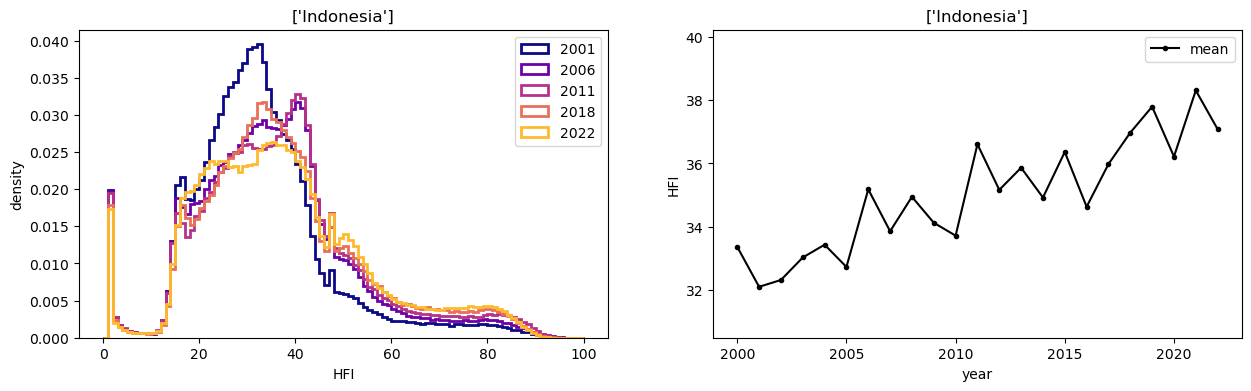

In [6]:
PLOT_YEARS = (2001, 2006, 2011, 2018, 2022)
N = len(PLOT_YEARS)
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.plasma(np.linspace(0, 0.85, N)))


plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
bins = np.arange(0, 101)
for year in PLOT_YEARS:
    plt.hist(
        pred_values_dict[year],
        bins=bins,
        density=True,
        histtype="step",
        label=str(year),
        linewidth=2,
    )

plt.title(COUNTRIES)
plt.xlabel("HFI")
plt.ylabel("density")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(YEARS, pred_mean, ".-", label="mean", color="k")
plt.legend()
plt.ylim(np.min(pred_mean) * 0.95, np.max(pred_mean) * 1.05)
plt.ylabel("HFI")
plt.xlabel("year")
plt.title(COUNTRIES)
plt.show()
